# 01. EDA - 서울시 지하철 원천 데이터 탐색
Raw 데이터 구조 파악, 결측치 확인, 기본 분포 탐색

In [1]:
import os
import glob
import matplotlib
import pandas as pd
import matplotlib.pyplot as plt

matplotlib.rc('font', family='Malgun Gothic')  # 한글 폰트
plt.rcParams['axes.unicode_minus'] = False

In [2]:
# Raw CSV 불러오기
raw_files = glob.glob('data/raw/subway/**/*.csv', recursive=True)
print(f'수집된 파일 수: {len(raw_files)}')

df = pd.concat([pd.read_csv(f) for f in raw_files], ignore_index=True)
print(f'전체 행 수: {len(df):,}')
df.head()

수집된 파일 수: 28
전체 행 수: 17,290


,USE_YMD,SBWY_ROUT_LN_NM,SBWY_STNS_NM,GTON_TNOPE,GTOFF_TNOPE,REG_YMD
0,20260401,1호선,서울역,84050,80764,20260404
1,20260401,1호선,시청,31698,31850,20260404
2,20260401,1호선,종각,46810,45566,20260404
3,20260401,1호선,종로3가,27731,24503,20260404
4,20260401,1호선,종로5가,26648,26386,20260404


In [3]:
# 컬럼 구조 확인
print('컬럼 목록:')
print(df.dtypes)
print()
print('결측치:')
print(df.isnull().sum())

컬럼 목록:
USE_YMD             int64
SBWY_ROUT_LN_NM    object
SBWY_STNS_NM       object
GTON_TNOPE          int64
GTOFF_TNOPE         int64
REG_YMD             int64
dtype: object

결측치:
USE_YMD            0
SBWY_ROUT_LN_NM    0
SBWY_STNS_NM       0
GTON_TNOPE         0
GTOFF_TNOPE        0
REG_YMD            0
dtype: int64


In [4]:
# 호선 분포
print('호선별 데이터 수:')
print(df['SBWY_ROUT_LN_NM'].value_counts())

호선별 데이터 수:
SBWY_ROUT_LN_NM
5호선         1568
2호선         1400
7호선         1177
경부선         1092
6호선         1085
분당선          978
3호선          952
경원선          924
경의선          760
4호선          728
9호선          700
중앙선          588
경인선          560
경춘선          532
8호선          532
수인선          504
공항철도 1호선     392
9호선2~3단계     364
우이신설선        364
안산선          364
경강선          336
신림선          308
일산선          298
1호선          280
과천선          224
장항선          196
서해선           84
Name: count, dtype: int64


In [5]:
# 수집 기간 확인
df['USE_YMD'] = pd.to_datetime(df['USE_YMD'].astype(str), format='%Y%m%d')
print(f'수집 기간: {df["USE_YMD"].min().date()} ~ {df["USE_YMD"].max().date()}')
print(f'총 일수: {df["USE_YMD"].nunique()}일')

수집 기간: 2026-04-01 ~ 2026-04-28
총 일수: 28일


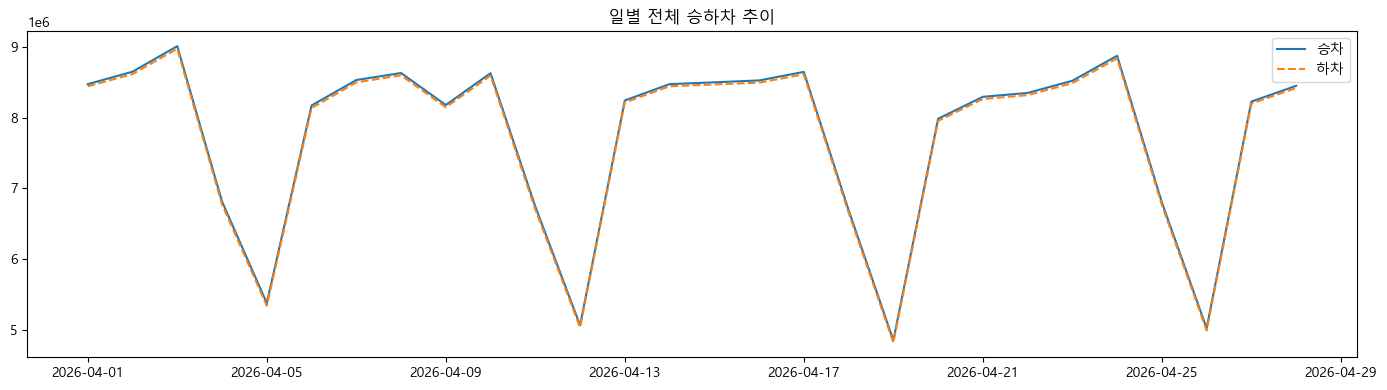

In [6]:
# 일별 총 승하차 추이
daily = df.groupby('USE_YMD')[['GTON_TNOPE', 'GTOFF_TNOPE']].sum()

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(daily.index, daily['GTON_TNOPE'], label='승차')
ax.plot(daily.index, daily['GTOFF_TNOPE'], label='하차', linestyle='--')
ax.set_title('일별 전체 승하차 추이')
ax.legend()
plt.tight_layout()
plt.show()

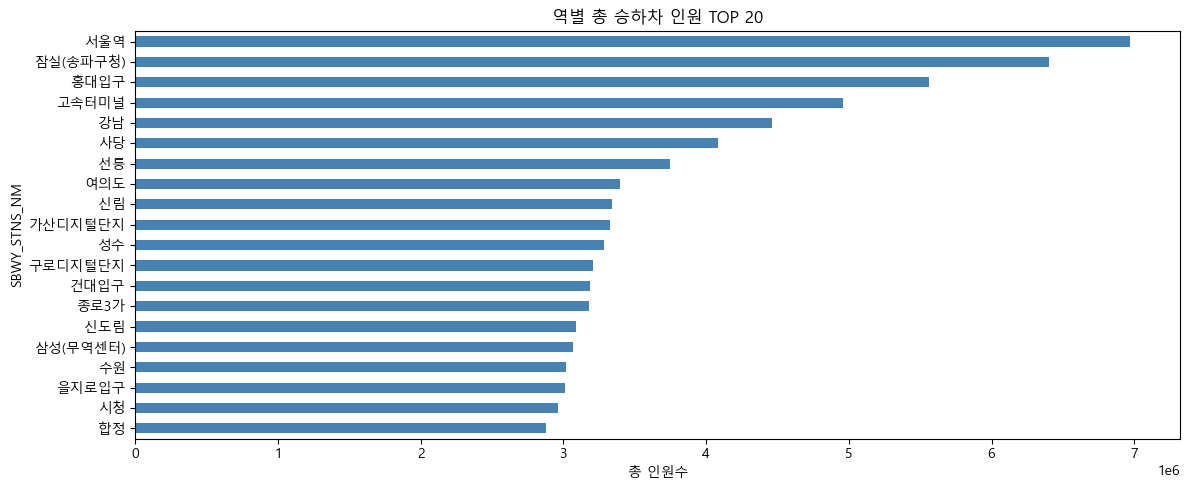

In [7]:
# 역별 총 승하차 TOP 20
top20 = df.groupby('SBWY_STNS_NM')[['GTON_TNOPE', 'GTOFF_TNOPE']].sum() \
    .assign(total=lambda x: x['GTON_TNOPE'] + x['GTOFF_TNOPE']) \
    .sort_values('total', ascending=False).head(20)

fig, ax = plt.subplots(figsize=(12, 5))
top20['total'].plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('역별 총 승하차 인원 TOP 20')
ax.set_xlabel('총 인원수')
ax.invert_yaxis()
plt.tight_layout()
plt.show()